Livrable 1 : Classification binaire

Etape 1 :

- Téléchargement du dataset
- Redimensionnement des images en `180 x 180`.
- Découpage en jeu d’entraînement et jeu de test.
- Optimisation du pipeline avec `cache()` et `prefetch()` pour accélérer l’apprentissage.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

I0000 00:00:1779114392.694323  581663 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779114392.695758  581663 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779114393.374502  581663 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779114401.061212  581663 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
import os
import tensorflow as tf

data_dir = "Dataset"
deleted = 0

print("Début du scan et du nettoyage des images...")

for subdir in os.listdir(data_dir):
    subdir_path = os.path.join(data_dir, subdir)
    if os.path.isdir(subdir_path):
        for file in os.listdir(subdir_path):
            filepath = os.path.join(subdir_path, file)
            try:
                # Tente de décoder l'image avec la même fonction TensorFlow utilisée par le Dataset
                image_string = tf.io.read_file(filepath)
                _ = tf.image.decode_image(image_string)
            except Exception as e:
                print(f"Fichier corrompu ou invalide détecté : {filepath}")
                try:
                    os.remove(filepath)
                    deleted += 1
                    print("-> Fichier supprimé avec succès.")
                except PermissionError:
                    print(f"-> Impossible de supprimer {filepath} : Droits administrateur requis.")
                except Exception as e_rm:
                    print(f"-> Erreur lors de la suppression de {filepath} : {e_rm}")

print(f"Nettoyage terminé. {deleted} images corrompues supprimées.")

Début du scan et du nettoyage des images...


E0000 00:00:1779114678.692606  581663 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779114678.693671  586440 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1779114678.757944  581663 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
W0000 00:00:1779114856.100632  581663 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


Fichier corrompu ou invalide supprimé : Dataset/Schematics/desktop.ini


W0000 00:00:1779115025.384680  581663 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: Unknown image file format. One of JPEG, JPEG XL, PNG, GIF, BMP, WebP required.


Nettoyage terminé. 1 images corrompues supprimées.


In [4]:
batch_size = 32
img_height = 180
img_width = 180
data_dir = "Dataset"

train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 41546 files belonging to 6 classes.
Using 33237 files for training.
Found 41546 files belonging to 6 classes.
Using 8309 files for validation.
['Dataset', 'Painting', 'Photo', 'Schematics', 'Sketch', 'Text']


Etape 2:

- Visualisation de plusieurs images pour comprendre la variété des données.
- Observation des difficultés : angles différents, luminosité variable, arrière-plans variés, présence d’objets parasites, Perte d'information critique avec le redimensionnement, Le biais lié à la couleur, Le bruit et les artefacts.


W0000 00:00:1779115156.258511  597863 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


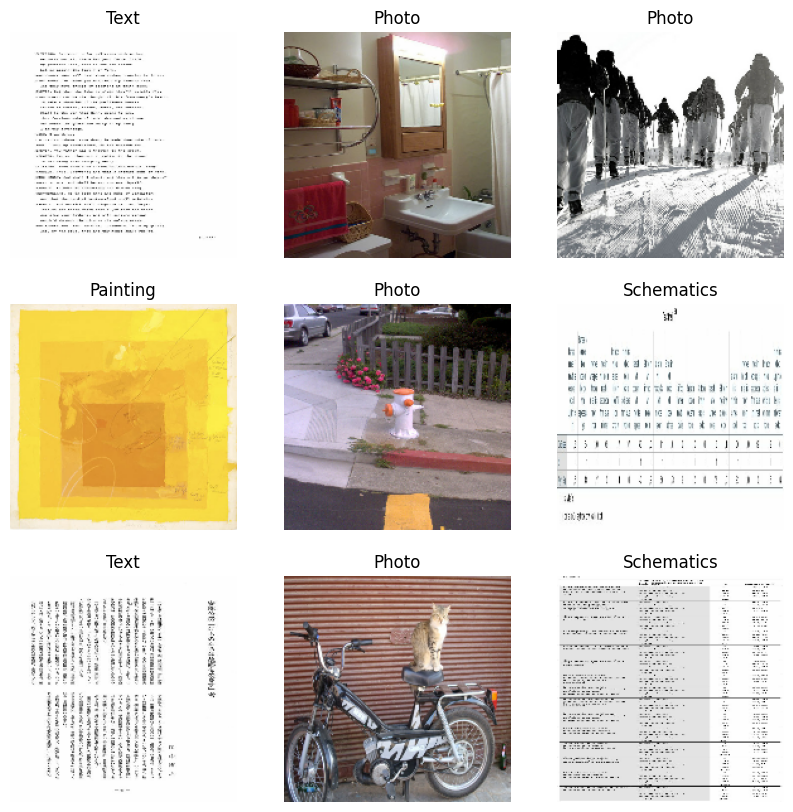

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

Etape 3 :

Construction d’un premier CNN
Le modèle construit comprend :

une normalisation des pixels avec Rescaling(1./255) ;
trois blocs convolutifs successifs :
Conv2D(16, 3x3) + MaxPooling2D,
Conv2D(32, 3x3) + MaxPooling2D,
Conv2D(64, 3x3) + MaxPooling2D ;
une couche Flatten ;
une couche dense de 128 neurones ;
une couche de sortie softmax pour classer les 6 datasets

In [6]:
num_classes = len(class_names) # 6 datasets

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model.summary()

/home/tt/Documents/projet-leyenda/tf_env/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,414 (15.22 MB)

 Trainable params: 3,989,414 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

### Explication des résultats obtenus jusqu’ici

- Optimiseur : `adam`
- Perte : `SparseCategoricalCrossentropy`
- Métrique : `accuracy`

Etape 4 : 

Les courbes d’accuracy et de loss permettent d’analyser les performances.

In [ ]:
epochs = 10

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Epoch 1/10
  35/1039 ━━━━━━━━━━━━━━━━━━━━ 5:41 340ms/step - accuracy: 0.4234 - loss: 1.4370